In [18]:
# OASIS Infobyte - Data Science Internship
# Task 2: Unemployment Analysis with Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Unemployment in India dataset directly
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv"

df = pd.read_csv(url)

# Display basic information
print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [19]:
# Clean column names
df.columns = df.columns.str.strip()

# Remove extra spaces from text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [20]:
# Basic dataset information

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (267, 9)

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
longitude                                         float64
latitude                                          float64
dtype: object

Descriptive Statistics:


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738



Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


Number of regions/states: 27

Regions/States:
['Andhra Pradesh' 'Tripura' 'Delhi' 'Telangana' 'Tamil Nadu' 'Goa'
 'Gujarat' 'Rajasthan' 'Haryana' 'Chhattisgarh' 'Punjab'
 'Himachal Pradesh' 'Odisha' 'Jammu & Kashmir' 'Meghalaya' 'Jharkhand'
 'Maharashtra' 'Karnataka' 'Madhya Pradesh' 'Puducherry' 'Uttar Pradesh'
 'Kerala' 'Bihar' 'Assam' 'Uttarakhand' 'West Bengal' 'Sikkim']


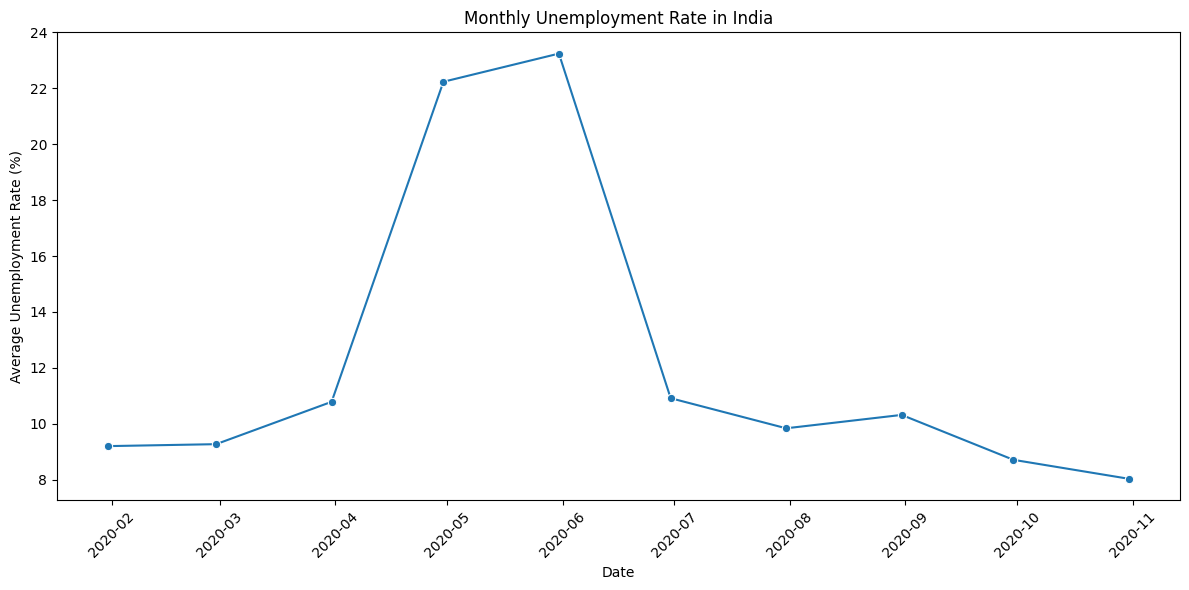

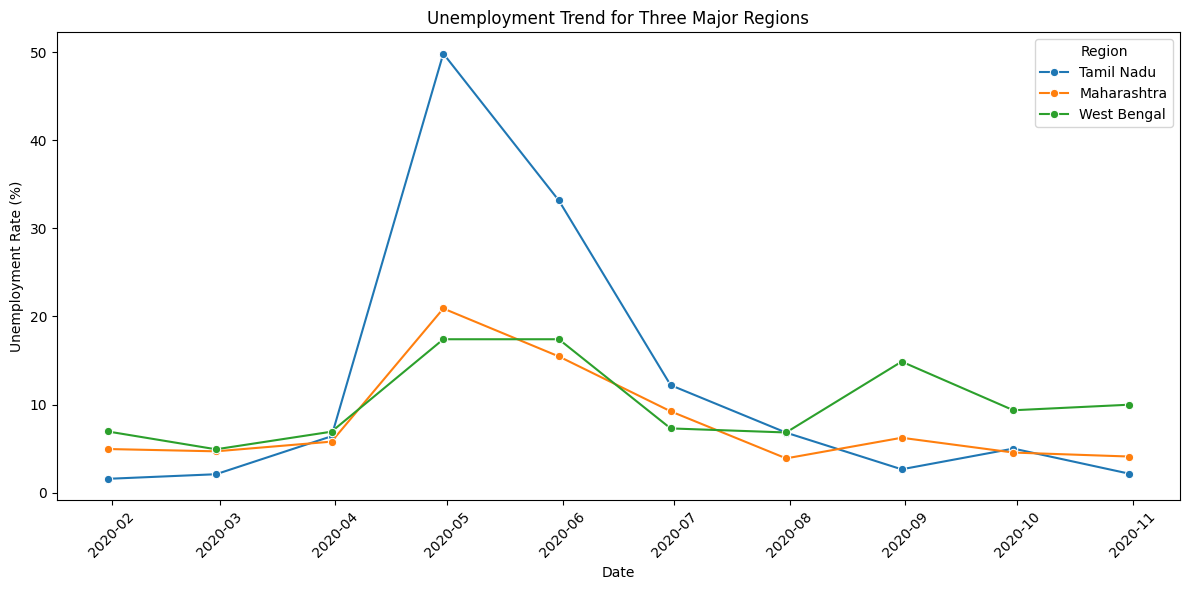

In [21]:
# ============================================================
# SECTION 2: REGIONAL AND TIME TREND ANALYSIS
# ============================================================

# Sort data by date
df = df.sort_values("Date")

# Check available regions/states
print("Number of regions/states:", df["Region"].nunique())

# Display the regions/states
print("\nRegions/States:")
print(df["Region"].unique())

# ------------------------------------------------------------
# Monthly average unemployment rate across India
# ------------------------------------------------------------

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Unemployment trend for three major regions
# ------------------------------------------------------------

selected_regions = ["Maharashtra", "West Bengal", "Tamil Nadu"]

region_data = df[df["Region"].isin(selected_regions)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=region_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Trend for Three Major Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.show()

Top 10 Regions by Average Unemployment Rate:


,Estimated Unemployment Rate (%)
Region,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


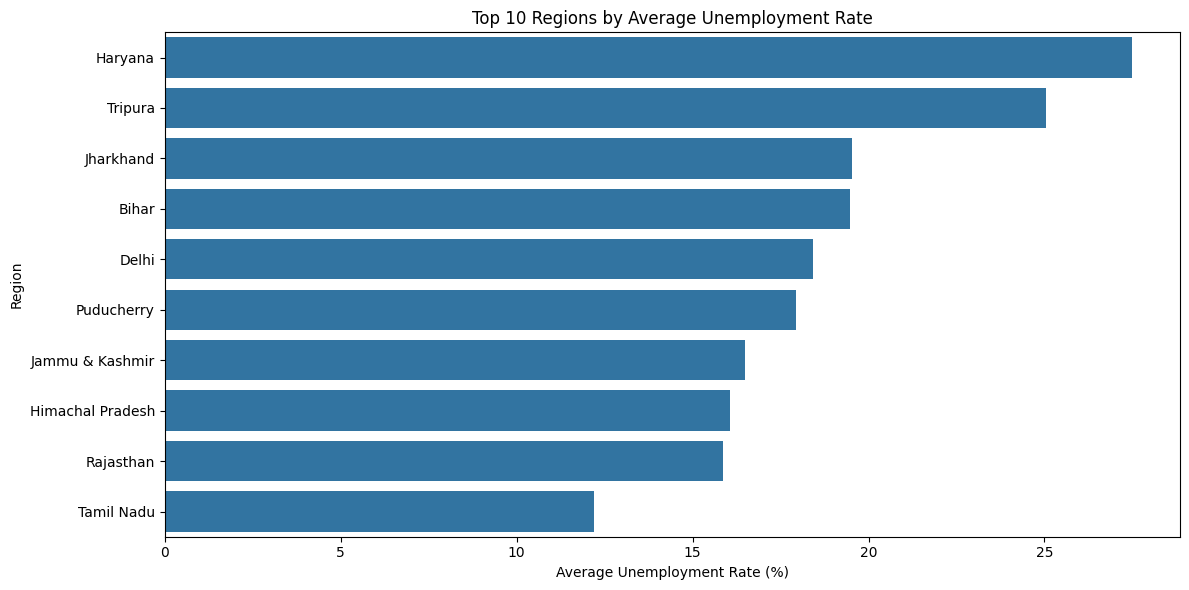

In [22]:
# ============================================================
# SECTION 3: TOP 10 REGIONS BY AVERAGE UNEMPLOYMENT
# ============================================================

# Calculate average unemployment rate for each region
avg_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

# Select top 10 regions
top_10_regions = avg_unemployment.head(10)

print("Top 10 Regions by Average Unemployment Rate:")
display(top_10_regions)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Correlation Matrix:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


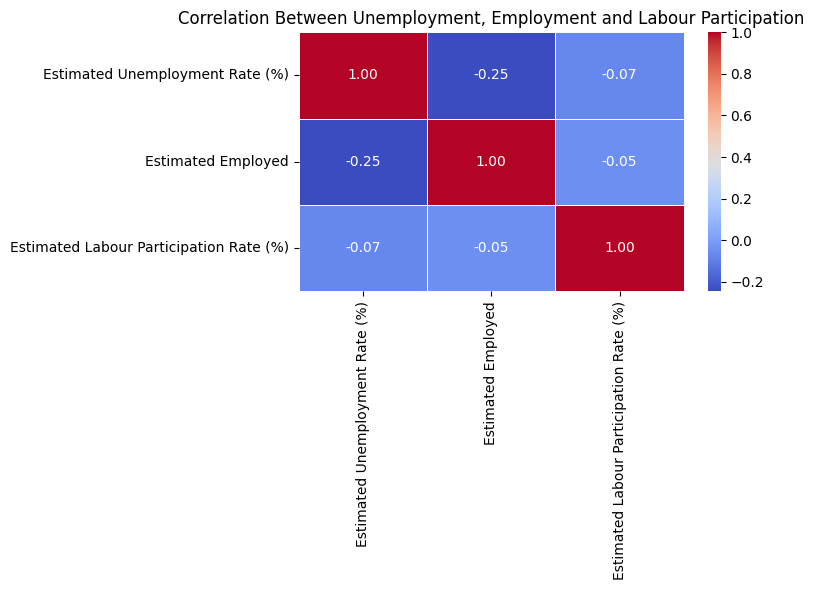

In [23]:
# ============================================================
# SECTION 4: CORRELATION ANALYSIS
# ============================================================

# Select numerical columns for correlation analysis
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Display correlation values
print("Correlation Matrix:")
display(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()

Average Unemployment Rate Before COVID-19: 9.23 %
Average Unemployment Rate During COVID-19: 16.74 %


,Period,Average Unemployment Rate (%)
0,Before COVID-19,9.231346
1,During COVID-19,16.742710


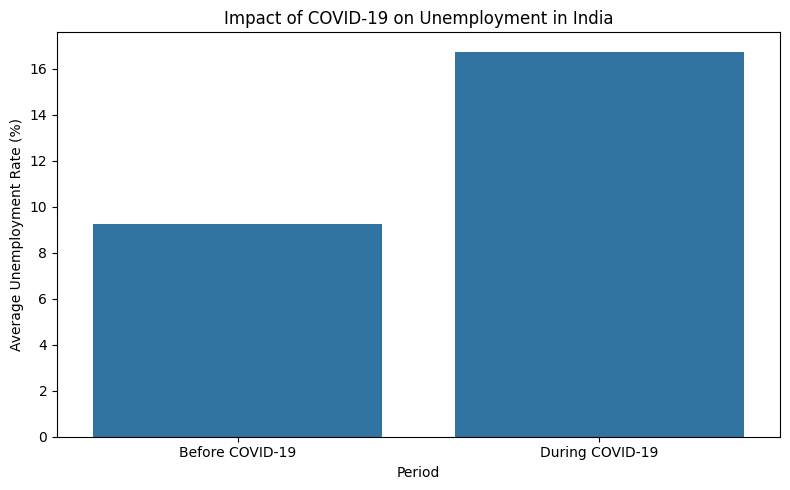

In [24]:
# ============================================================
# SECTION 5: COVID-19 IMPACT ANALYSIS
# ============================================================

# Define pre-COVID and COVID periods
pre_covid = df[df["Date"] < "2020-03-01"]
covid_period = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]

# Calculate average unemployment rate
pre_covid_rate = pre_covid["Estimated Unemployment Rate (%)"].mean()
covid_rate = covid_period["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate Before COVID-19:",
      round(pre_covid_rate, 2), "%")

print("Average Unemployment Rate During COVID-19:",
      round(covid_rate, 2), "%")

# Compare the two periods
comparison = pd.DataFrame({
    "Period": ["Before COVID-19", "During COVID-19"],
    "Average Unemployment Rate (%)": [
        pre_covid_rate,
        covid_rate
    ]
})

display(comparison)

# Plot comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate (%)"
)

plt.title("Impact of COVID-19 on Unemployment in India")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# SECTION 6: FINAL OBSERVATIONS
# ============================================================

# Find the region with the highest average unemployment
highest_unemployment_region = avg_unemployment.idxmax()
highest_unemployment_rate = avg_unemployment.max()

# Find the region with the lowest average unemployment
lowest_unemployment_region = avg_unemployment.idxmin()
lowest_unemployment_rate = avg_unemployment.min()

print("KEY OBSERVATIONS")
print("-" * 50)

print(
    f"1. {highest_unemployment_region} had the highest "
    f"average unemployment rate of {highest_unemployment_rate:.2f}%."
)

print(
    f"2. {lowest_unemployment_region} had the lowest "
    f"average unemployment rate of {lowest_unemployment_rate:.2f}%."
)

print(
    f"3. The average unemployment rate before COVID-19 was "
    f"{pre_covid_rate:.2f}%."
)

print(
    f"4. The average unemployment rate during the COVID-19 period "
    f"was {covid_rate:.2f}%."
)

print(
    "5. The time-series analysis shows that unemployment rates "
    "varied across regions and over time."
)

print(
    "6. The correlation heatmap helps identify relationships "
    "between unemployment, employment and labour participation."
)

KEY OBSERVATIONS
--------------------------------------------------
1. Haryana had the highest average unemployment rate of 27.48%.
2. Meghalaya had the lowest average unemployment rate of 3.87%.
3. The average unemployment rate before COVID-19 was 9.23%.
4. The average unemployment rate during the COVID-19 period was 16.74%.
5. The time-series analysis shows that unemployment rates varied across regions and over time.
6. The correlation heatmap helps identify relationships between unemployment, employment and labour participation.


## Conclusion

The Unemployment Analysis project examined unemployment trends across different regions of India over time.

The analysis included regional and monthly unemployment trends, comparison of major regions, the top 10 regions with the highest average unemployment rates, and correlations between unemployment, employment, and labour participation.

The COVID-19 period was also compared with the pre-COVID period to understand its impact on unemployment.

Overall, the analysis shows that unemployment rates varied across regions and changed over time, with a noticeable impact during the COVID-19 period.